<div style="
    font-family: 'Poppins', sans-serif;
    background-color: #003366;
    color: white;
    width: 700px;
    padding: 50px;
    border-radius: 25px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
">
    <h1 style="font-size: 42px; margin-bottom: 25px;">Jose Carlos Fernandez</h1>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Fecha:</strong> 07/01/2025</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Maestro:</strong> Persio Martinez</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Instituto Tenológico de Las Américas ITLA<p>
</div>


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 1️⃣: Obtener CSV con la informacion de la tabla `Orders`**

**Profe, yo he decidido obtener el CSV con la información de la tabla `sales.orders` desde aqui mismo, entonces voy a proceder con la conexion y extraccion**

In [14]:
import pyodbc
import pandas as pd

# Conexion
conn = pyodbc.connect(
    'DRIVER={SQL Server};SERVER=JC-COMPUTER\SQLEXPRESS;DATABASE=BikeStores;Trusted_Connection=yes;'
)

# Query para obtener datos
df = pd.read_sql("SELECT * FROM sales.orders", conn)

# Almacenamiento de datos en un archivo CSV
df.to_csv('D:\\OneDrive - Instituto Tecnológico de Las Américas (ITLA)\\orders.csv', index=False) # Lo guarde en la carpeta de OneDrive con el nombre de orders.csv


<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6164\1833062534.py:6: SyntaxWarning: invalid escape sequence '\S'
  'DRIVER={SQL Server};SERVER=JC-COMPUTER\SQLEXPRESS;DATABASE=BikeStores;Trusted_Connection=yes;'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6164\1833062534.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM sales.orders", conn)


**✅ Ready, entonces ahora chequeamos el contenido de mi DataFrame**

In [15]:
df

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2
1,2,1212,4,2016-01-01,2016-01-04,2016-01-03,2,6
2,3,523,4,2016-01-02,2016-01-05,2016-01-03,2,7
3,4,175,4,2016-01-03,2016-01-04,2016-01-05,1,3
4,5,1324,4,2016-01-03,2016-01-06,2016-01-06,2,6
...,...,...,...,...,...,...,...,...
1610,1611,6,3,2018-09-06,2018-09-06,None,2,7
1611,1612,3,3,2018-10-21,2018-10-21,None,1,3
1612,1613,1,3,2018-11-18,2018-11-18,None,2,6
1613,1614,135,3,2018-11-28,2018-11-28,None,3,8


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 2️⃣: Crear una base de datos en MongoDb llamada `BikeStore`.**

**Para algo instalamos la libreria `pymongo`... entonces llego la hora de usarla. La voy a usar para conectarme a `MongoDB` y crear la base de datos**

In [16]:
from pymongo import MongoClient
import pandas as pd

# Conexion a MongoDB (obviamente hay que tener MongoDB corriendo)
client = MongoClient("mongodb://localhost:27017/") # En clase vimos que MongoDB por defecto escucha en el puerto 27017

# Creamos base de datos
db = client["BikeStore"] # Usamos `client` para crear una base de datos

**✅ Ready, ahora chequeamos la variable `db` para ver si estamos conectados a la base de datos correctamente:**

In [17]:
db

Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'BikeStore')

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 3️⃣: Crear colección `Facturas`**

**Una colección en MongoDB es como una tabla en SQL basicamente**

In [18]:
facturas = db["Facturas"]

**✅ Ready, entonces vamos a ver el tipo de objeto que creamos:**

In [19]:
facturas

Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'BikeStore'), 'Facturas')

**Vemos claramente que es un objeto de tipo `Collection`**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 4️⃣: Cargar el CSV en la colección `Facturas`**

**Hace rato creamos un CSV con el nombre de `orders`, entonces vamos a tomar ese archivo e insertarlo en la coleccion `Facturas`**

In [20]:
ruta = r"D:\OneDrive - Instituto Tecnológico de Las Américas (ITLA)\orders.csv" # Ruta del archivo CSV

df = pd.read_csv(ruta) # Leemos el CSV y lo convertimos a un DataFrame de pandas

data = df.to_dict(orient="records") # Convertimos el DataFrame a un diccionario de registros, donde cada fila es un diccionario o documento como deciamos en clase

facturas.insert_many(data) # Insertamos los datos en la colección `Facturas`

InsertManyResult([ObjectId('6864bb50a743f32bc6ae2972'), ObjectId('6864bb50a743f32bc6ae2973'), ObjectId('6864bb50a743f32bc6ae2974'), ObjectId('6864bb50a743f32bc6ae2975'), ObjectId('6864bb50a743f32bc6ae2976'), ObjectId('6864bb50a743f32bc6ae2977'), ObjectId('6864bb50a743f32bc6ae2978'), ObjectId('6864bb50a743f32bc6ae2979'), ObjectId('6864bb50a743f32bc6ae297a'), ObjectId('6864bb50a743f32bc6ae297b'), ObjectId('6864bb50a743f32bc6ae297c'), ObjectId('6864bb50a743f32bc6ae297d'), ObjectId('6864bb50a743f32bc6ae297e'), ObjectId('6864bb50a743f32bc6ae297f'), ObjectId('6864bb50a743f32bc6ae2980'), ObjectId('6864bb50a743f32bc6ae2981'), ObjectId('6864bb50a743f32bc6ae2982'), ObjectId('6864bb50a743f32bc6ae2983'), ObjectId('6864bb50a743f32bc6ae2984'), ObjectId('6864bb50a743f32bc6ae2985'), ObjectId('6864bb50a743f32bc6ae2986'), ObjectId('6864bb50a743f32bc6ae2987'), ObjectId('6864bb50a743f32bc6ae2988'), ObjectId('6864bb50a743f32bc6ae2989'), ObjectId('6864bb50a743f32bc6ae298a'), ObjectId('6864bb50a743f32bc6ae29

**Aqui lo que estamos haciendo basicamente es:**

- **Creando una ruta absoluta de donde esta mi archivo CSV**
- **Luego, leemos esa ruta con `read_csv` y lo almacenamos en un DataFrame llamado `df`**
- **Posteriormente, convertimos ese DataFrame a un Diccionario... esto lo hacemos porque tenemos la intencion de manipular `JSON`**
- (**En clase estuve diciendo que `JSON` es como tablas `SQL` pero en formato de diccionario, entonces esa definicion encaja perfectamente ahora)**
- **Por ultimo, en lugar de hacer un `INSERT INTO` como en `SQL`... hacemos un `insert_many` a nuestra coleecion `facturas`, insertandole el diccionario o JSON que llamamos `data`**

**✅ Ready, entonces ahora veamos los 5 primeros registros para asegurarnos que todo salio bien**

In [21]:
print("\nPrimeros 5 documentos en la coleccion 'Facturas':")
for doc in facturas.find().limit(5): 
    print(doc)


Primeros 5 documentos en la coleccion 'Facturas':
{'_id': ObjectId('6864b0c0a743f32bc6ae2323'), 'order_id': 2, 'customer_id': 1212, 'order_status': 4, 'order_date': '2016-01-01', 'required_date': '2016-01-04', 'shipped_date': '2016-01-03', 'store_id': 2, 'staff_id': 6}
{'_id': ObjectId('6864b0c0a743f32bc6ae2324'), 'order_id': 3, 'customer_id': 523, 'order_status': 4, 'order_date': '2016-01-02', 'required_date': '2016-01-05', 'shipped_date': '2016-01-03', 'store_id': 2, 'staff_id': 7}
{'_id': ObjectId('6864b0c0a743f32bc6ae2326'), 'order_id': 5, 'customer_id': 1324, 'order_status': 4, 'order_date': '2016-01-03', 'required_date': '2016-01-06', 'shipped_date': '2016-01-06', 'store_id': 2, 'staff_id': 6}
{'_id': ObjectId('6864b0c0a743f32bc6ae2327'), 'order_id': 6, 'customer_id': 94, 'order_status': 4, 'order_date': '2016-01-04', 'required_date': '2016-01-07', 'shipped_date': '2016-01-05', 'store_id': 2, 'staff_id': 6}
{'_id': ObjectId('6864b0c0a743f32bc6ae2328'), 'order_id': 7, 'customer_i

**PD: los `order_id` no estan en orden porque ejecute esta celda despues de eliminar algunos registros 😅**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 5️⃣: Desde la consola identificar todos los documentos donde el estado de la factura sea 3**

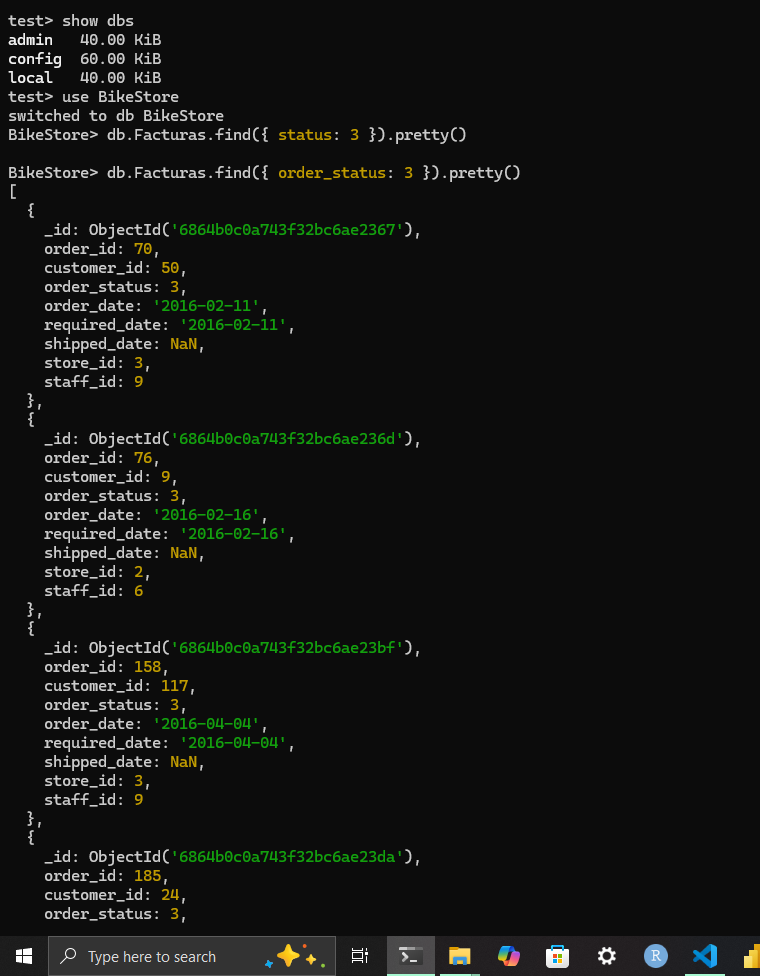

**Esta consulta (`db.Facturas.find({ status: 3 }).pretty()`) basicamente lo que hace es:**

- **Usar `db` para referirnos a la base de datos actual, en este caso fue `BikeStore`, la cual fue creada en el paso 2**
- **`.Facturas` es la coleccion que esta en esa bae de datos**
- **`.find({ order_status: 3 })` busca todos los documentos donde el campo order_status sea igual a 3.**
- **`.Facturas` es la coleccion que esta en esa bae de datos**
- **`.pretty()` muestra los documentos con un formato legible y bien indentado en la consola.**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 6️⃣: Desde Mongodb Compass filtrar todos los documentos del cliente Jayne Kirkland (customer id 68).**

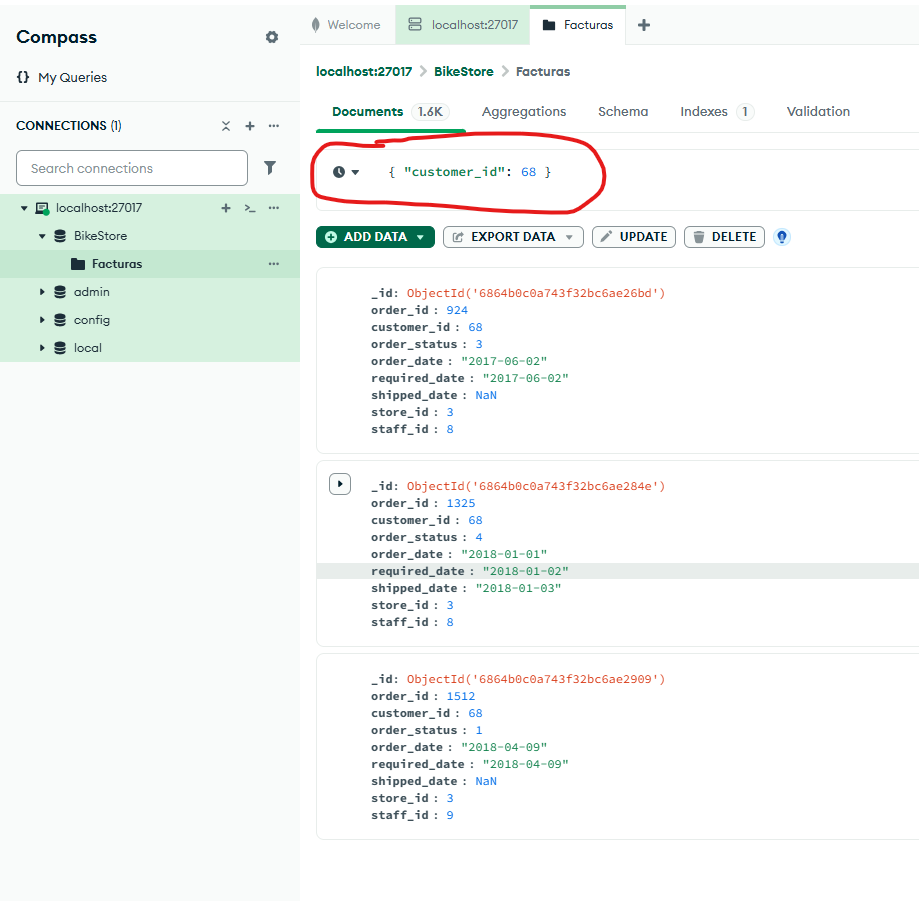

**✅ Ready... No hay mucho que decir de esta consulta 😂😂, simplemente un filtrico que me da los regisros cuyo `customer_id` sea `68`**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 7️⃣: Desde la consola eliminar todos los documentos que son de la tienda `Santa Cruz Bikes` (`store_id = 1`)**

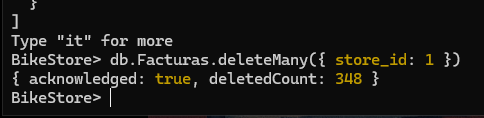

**De aqui podemos decir que:**

- **Asi como hay `inser_many` tambien hay un `delete_Many`... `Pros` y `Contras`**
- **Vemos que se eliminaron `348` registros que cumplen con la condicion de `store_id = 1`**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **Objetivo 8️⃣: Consultas todos los documentos desde Python.**

In [22]:
todos = facturas.find() # Obtenemos todos los documentos de la coleccion 'Facturas'

# Imprimimos todos los documentos para verificar que se insertaron correctamente
print("📄 Todos los documentos en la coleccion 'Facturas':\n")
for doc in todos:
    print(doc)

📄 Todos los documentos en la coleccion 'Facturas':

{'_id': ObjectId('6864b0c0a743f32bc6ae2323'), 'order_id': 2, 'customer_id': 1212, 'order_status': 4, 'order_date': '2016-01-01', 'required_date': '2016-01-04', 'shipped_date': '2016-01-03', 'store_id': 2, 'staff_id': 6}
{'_id': ObjectId('6864b0c0a743f32bc6ae2324'), 'order_id': 3, 'customer_id': 523, 'order_status': 4, 'order_date': '2016-01-02', 'required_date': '2016-01-05', 'shipped_date': '2016-01-03', 'store_id': 2, 'staff_id': 7}
{'_id': ObjectId('6864b0c0a743f32bc6ae2326'), 'order_id': 5, 'customer_id': 1324, 'order_status': 4, 'order_date': '2016-01-03', 'required_date': '2016-01-06', 'shipped_date': '2016-01-06', 'store_id': 2, 'staff_id': 6}
{'_id': ObjectId('6864b0c0a743f32bc6ae2327'), 'order_id': 6, 'customer_id': 94, 'order_status': 4, 'order_date': '2016-01-04', 'required_date': '2016-01-07', 'shipped_date': '2016-01-05', 'store_id': 2, 'staff_id': 6}
{'_id': ObjectId('6864b0c0a743f32bc6ae2328'), 'order_id': 7, 'customer_

**🔵Este código muestra todos los documentos guardados en la colección Facturas de la base de datos BikeStore, impresos uno a uno en la consola.🔵**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background-color: #28a745; color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center;">
        FIN
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: #ddd;">Jose Carlos Fernandez</p>
    </div>
</div>
